# Nahaufnahme des $(p,h)$-Raums

Für $n=400$ werden die Prognosegrenzen
$$
h=p\pm 1{,}64\sqrt{\frac{p(1-p)}{400}}
$$
und die beiden Punkte $(0{,}14;0{,}17)$ und $(0{,}20;0{,}17)$ dargestellt. Obwohl $h=0{,}17$ von beiden Parameterwerten den Abstand $0{,}03$ hat, liegt nur der zweite Punkt im Prognoseband.

p=0.14: h=0.17 liegt außerhalb des Prognosebands.
p=0.20: h=0.17 liegt innerhalb des Prognosebands.


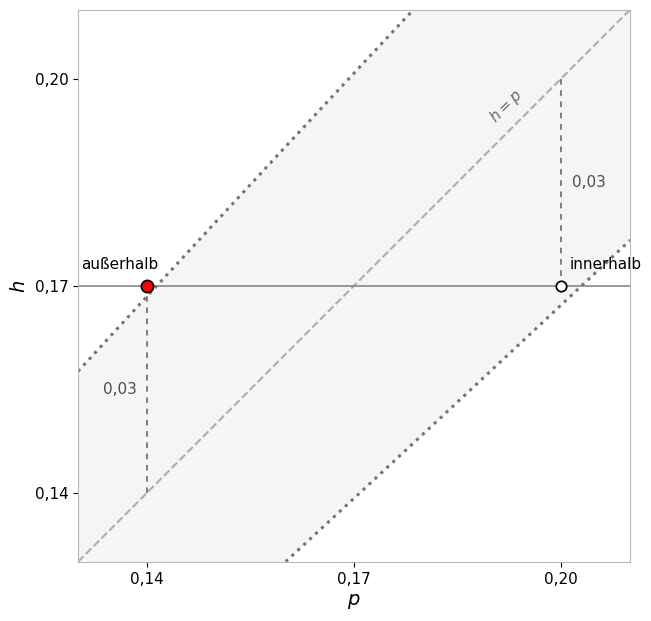

In [18]:
from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import numpy as np


@dataclass(frozen=True)
class Parameter:
    n: int = 400
    z: float = 1.64  # Grenze aus dem Erwartungshorizont
    h: float = 0.17
    p_werte: tuple[float, float] = (0.14, 0.20)
    achsenminimum: float = 0.13
    achsenmaximum: float = 0.21


def prognosegrenzen(
    p: np.ndarray, n: int, z: float
) -> tuple[np.ndarray, np.ndarray]:
    radius = z * np.sqrt(p * (1 - p) / n)
    return p - radius, p + radius


def dezimalkomma(wert: float, position: int) -> str:
    return f"{wert:.2f}".replace(".", ",")


def zeichne_nahaufnahme(
    parameter: Parameter,
) -> tuple[plt.Figure, np.ndarray]:
    p = np.linspace(
        parameter.achsenminimum, parameter.achsenmaximum, 2001
    )
    untergrenze, obergrenze = prognosegrenzen(
        p, parameter.n, parameter.z
    )

    p_punkte = np.asarray(parameter.p_werte)
    h_punkte = np.full_like(p_punkte, parameter.h)
    unten_punkte, oben_punkte = prognosegrenzen(
        p_punkte, parameter.n, parameter.z
    )
    innerhalb = (unten_punkte <= h_punkte) & (h_punkte <= oben_punkte)

    fig, ax = plt.subplots(figsize=(6.4, 6.4), constrained_layout=True)

    # Prognoseband und seine Mittellinie h=p
    ax.fill_between(
        p, untergrenze, obergrenze, color="0.96", zorder=0
    )
    ax.plot(
        p, untergrenze, color="0.45", linestyle=":", linewidth=2.2
    )
    ax.plot(
        p, obergrenze, color="0.45", linestyle=":", linewidth=2.2
    )
    ax.plot(
        p, p, color="0.68", linestyle="--", linewidth=1.5, zorder=1
    )

    # Die gleiche Realisation h=0,17 für beide Parameterwerte
    ax.axhline(
        parameter.h, color="0.55", linewidth=1.25, zorder=1
    )

    # Gleiche vertikale Abstände |h-p| zur Geraden h=p
    for p_wert in p_punkte:
        ax.plot(
            [p_wert, p_wert],
            [p_wert, parameter.h],
            color="0.48",
            linestyle=(0, (3, 3)),
            linewidth=1.35,
            zorder=2,
        )
        links_von_h = p_wert < parameter.h
        ax.text(
            p_wert + (-0.0015 if links_von_h else 0.0015),
            (p_wert + parameter.h) / 2,
            f"{abs(parameter.h - p_wert):.2f}".replace(".", ","),
            ha="right" if links_von_h else "left",
            va="center",
            fontsize=11,
            color="0.30",
        )

    # Innerhalb: weiß; außerhalb: rot
    ax.scatter(
        p_punkte[innerhalb],
        h_punkte[innerhalb],
        s=56,
        facecolors="white",
        edgecolors="black",
        linewidths=1.25,
        zorder=4,
    )
    ax.scatter(
        p_punkte[~innerhalb],
        h_punkte[~innerhalb],
        s=76,
        facecolors="red",
        edgecolors="black",
        linewidths=1.3,
        zorder=5,
    )

    for p_wert, ist_innerhalb in zip(p_punkte, innerhalb):
        links_von_h = p_wert < parameter.h
        ax.annotate(
            "innerhalb" if ist_innerhalb else "außerhalb",
            (p_wert, parameter.h),
            xytext=(8 if links_von_h else 6, 10),
            textcoords="offset points",
            ha="right" if links_von_h else "left",
            va="bottom",
            fontsize=11,
        )

    diagonalposition = parameter.achsenmaximum - 0.018
    ax.text(
        diagonalposition,
        diagonalposition + 0.001,
        r"$h=p$",
        rotation=45,
        ha="center",
        va="bottom",
        fontsize=11,
        color="0.42",
    )

    ax.set(
        xlim=(parameter.achsenminimum, parameter.achsenmaximum),
        ylim=(parameter.achsenminimum, parameter.achsenmaximum),
        xlabel=r"$p$",
        ylabel=r"$h$",
    )
    ax.set_aspect("equal")
    wichtige_werte = sorted({*parameter.p_werte, parameter.h})
    ax.set_xticks(wichtige_werte)
    ax.set_yticks(wichtige_werte)
    ax.xaxis.set_major_formatter(FuncFormatter(dezimalkomma))
    ax.yaxis.set_major_formatter(FuncFormatter(dezimalkomma))

    for spine in ax.spines.values():
        spine.set_color("0.72")
    ax.tick_params(labelsize=11)
    ax.xaxis.label.set_size(14)
    ax.yaxis.label.set_size(14)

    return fig, innerhalb


PARAMETER = Parameter()
ausgabeordner = Path.cwd()
abbildung, innerhalb = zeichne_nahaufnahme(PARAMETER)

abbildung.savefig(
    ausgabeordner / "Nahaufnahme-ph-Raum.pdf", bbox_inches="tight"
)
abbildung.savefig(
    ausgabeordner / "Nahaufnahme-ph-Raum.png",
    dpi=300,
    bbox_inches="tight",
)

for p_wert, ist_innerhalb in zip(PARAMETER.p_werte, innerhalb):
    lage = "innerhalb" if ist_innerhalb else "außerhalb"
    print(
        f"p={p_wert:.2f}: h={PARAMETER.h:.2f} liegt {lage} "
        "des Prognosebands."
    )

plt.show()
